## Project Objective

The objective of this project is to perform **Exploratory Data Analysis (EDA)** on the Zomato restaurant dataset to extract meaningful insights about the food delivery ecosystem.

This analysis focuses on:

- **Restaurant Distribution:** Examining the distribution of restaurants across different locations to identify high-demand areas  
- **Customer Behavior:** Analyzing features such as online ordering, table booking, votes, and reviews to understand user engagement  
- **Cuisine Analysis:** Identifying popular cuisines and understanding customer food preferences  
- **Price Range Analysis:** Studying cost patterns and their influence on customer choices  
- **Ratings & Popularity:** Evaluating the relationship between ratings and votes to assess restaurant performance  
- **Restaurant Type Analysis:** Exploring different categories of restaurants and their impact on demand  
- **Data Quality Assessment:** Identifying missing or inconsistent data affecting analysis  

### Goal

To derive actionable insights that help in understanding market trends, improving customer experience, and supporting data-driven decision-making in the food-tech industry.

In [3]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




In [6]:
#create dataframe
df=pd.read_csv("zomato.csv" , encoding = "latin-1")
df.head() #returns first five records

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [8]:
df.shape

(51717, 17)

In [9]:
df.columns


Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [12]:
df.describe()

,votes
count,51717.000000
mean,283.697527
std,803.838853
min,0.000000
25%,7.000000
50%,41.000000
75%,198.000000
max,16832.000000


In [ ]:
#drop unnecessary columns
# df.drop([<column name>], axis=1,, inplace=True)


In [13]:
#to check missing values
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [17]:
#Location-wise restaurants distribution
location_count = df['location'].value_counts()
location_count.head()

location
BTM                      5124
HSR                      2523
Koramangala 5th Block    2504
JP Nagar                 2235
Whitefield               2144
Name: count, dtype: int64

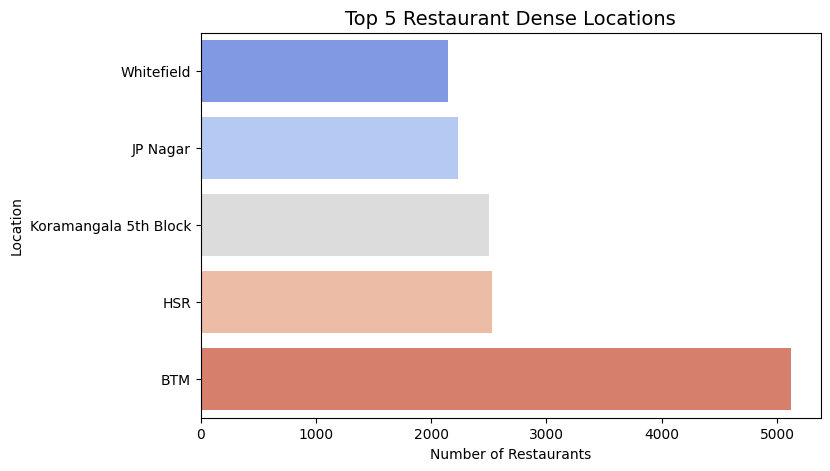

In [21]:
#visualisation
top_locations = df['location'].value_counts().head(5).sort_values()



plt.figure(figsize=(8,5))
sns.barplot(
    x=top_locations.values, 
    y=top_locations.index, 
    hue=top_locations.index, 
    palette="coolwarm",
    legend=False
)

plt.title("Top 5 Restaurant Dense Locations", fontsize=14)
plt.xlabel("Number of Restaurants")
plt.ylabel("Location")

plt.show()

### Restaurant Distribution Across Top Locations

The bar chart illustrates the top 5 locations with the highest number of restaurants in the dataset.

- **BTM has the highest concentration of restaurants**, indicating it is a major food hub with strong demand and high competition.
- **HSR and Koramangala 5th Block** also show significant restaurant density, reflecting their popularity among customers.
- **JP Nagar and Whitefield** have comparatively lower counts but still represent important market areas.

### Key Insights

- The distribution is **highly skewed**, with a few locations accounting for a large share of restaurants.
- High-density areas are likely to have:
  - Greater customer demand  
  - Higher competition among restaurants  
  - Faster delivery ecosystems  

- Locations with relatively lower density may represent:
  - Emerging markets  
  - Opportunities for new restaurant setups  

### Conclusion

Restaurant distribution is concentrated in specific urban hotspots, indicating demand-driven clustering. This insight can help businesses in deciding optimal locations for expansion and competitive positioning.

In [23]:
#market share of each location in percentage
location_pct = (df['location'].value_counts(normalize=True) * 100).head(5)

print(location_pct)

location
BTM                      9.911792
HSR                      4.880455
Koramangala 5th Block    4.843702
JP Nagar                 4.323352
Whitefield               4.147323
Name: proportion, dtype: float64


### Market Share of Top Locations

The above output represents the percentage share of restaurants in the top 5 locations relative to the total dataset.

- **BTM holds the highest market share (~9.9%)**, indicating a strong concentration of restaurants and high demand in this area.
- **HSR and Koramangala 5th Block each contribute around 4.8%**, showing they are also significant food hubs.
- **JP Nagar and Whitefield contribute approximately 4–4.3%**, reflecting moderate presence in the ecosystem.

### Key Insights

- The distribution is **uneven**, with BTM alone accounting for nearly double the share of other top locations.
- A small number of locations dominate the restaurant market, indicating **geographical clustering**.
- High market share areas are likely to experience:
  - Intense competition  
  - High customer demand  
  - Greater visibility for restaurants  

- Locations with lower shares may indicate:
  - Less saturation  
  - Potential opportunities for expansion  

### Conclusion

Market share analysis highlights the relative dominance of specific locations, providing a clearer understanding of how restaurants are distributed across the city beyond absolute counts.

In [28]:
# remove '/5' and handle non-numeric values
df['rate'] = df['rate'].astype(str).str.replace('/5', '')

# convert to numeric
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

top_rated_locations = (
    df.groupby('location')['rate']
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

print(top_rated_locations)

location
Lavelle Road             4.142505
Koramangala 3rd Block    4.020419
St. Marks Road           4.017201
Koramangala 5th Block    4.005821
Church Street            3.992125
Name: rate, dtype: float64


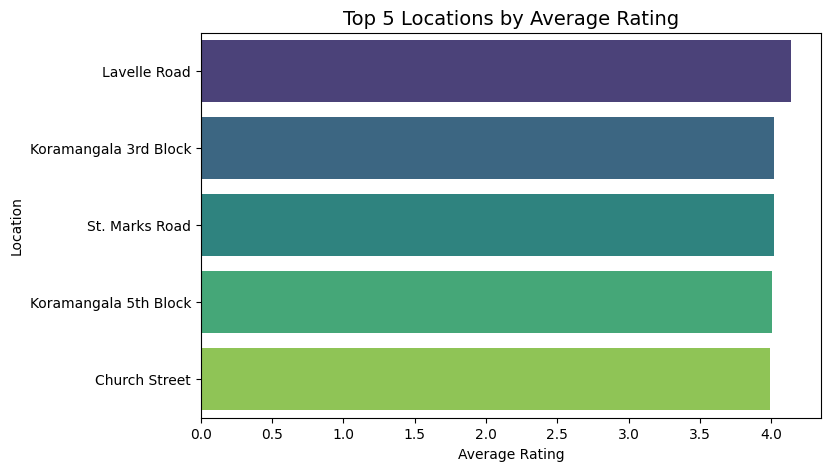

In [29]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=top_rated_locations.values,
    y=top_rated_locations.index,
    hue=top_rated_locations.index,
    palette="viridis",
    legend=False
)

plt.title("Top 5 Locations by Average Rating", fontsize=14)
plt.xlabel("Average Rating")
plt.ylabel("Location")

plt.show()

### Location vs Average Ratings

The analysis identifies the top 5 locations based on the average restaurant ratings.

- **Lavelle Road has the highest average rating (~4.14)**, indicating consistently high customer satisfaction.
- **Koramangala 3rd Block and St. Marks Road** also exhibit strong ratings, reflecting high-quality dining experiences.
- **Koramangala 5th Block and Church Street** maintain ratings close to 4.0, suggesting reliable performance.

### Key Insights

- These locations are not the ones with the highest restaurant density, indicating that **lower density areas can achieve higher quality ratings**.
- Many of these areas are known for **premium dining and upscale restaurants**, which may contribute to better service and customer experience.
- In contrast, high-density locations often show more variation in ratings due to increased competition and diverse restaurant types.

### Conclusion

The results support the observation that **restaurant quality is not solely dependent on quantity**. Certain locations outperform others in terms of customer satisfaction despite having fewer establishments, highlighting the importance of service quality and positioning in the market.

In [30]:
#computing location vs votes

top_voted_locations = (
    df.groupby('location')['votes']
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

print(top_voted_locations)

location
Church Street            1045.657293
Lavelle Road              956.873346
Koramangala 5th Block     886.384185
St. Marks Road            755.963068
Koramangala 4th Block     673.703048
Name: votes, dtype: float64


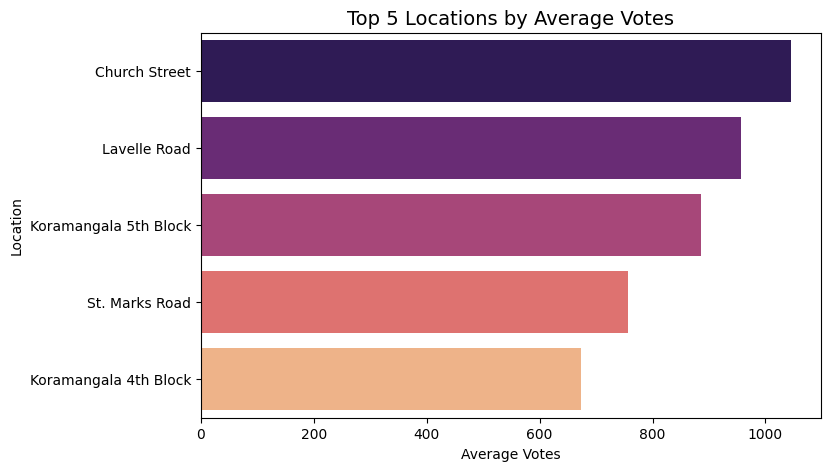

In [31]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=top_voted_locations.values,
    y=top_voted_locations.index,
    hue=top_voted_locations.index,
    palette="magma",
    legend=False
)

plt.title("Top 5 Locations by Average Votes", fontsize=14)
plt.xlabel("Average Votes")
plt.ylabel("Location")

plt.show()

### Location vs Popularity (Votes)

The analysis highlights the top 5 locations based on the average number of votes received by restaurants, which serves as a proxy for customer engagement and popularity.

- Locations with higher average votes indicate **greater customer interaction and visibility**.
- These areas are likely to have restaurants that are more frequently reviewed and ordered from.

### Key Insights

- High average votes suggest **strong customer engagement and popularity**.
- Popular locations may benefit from:
  - Higher footfall and online traffic  
  - Increased brand visibility  
  - Better customer recall  

- Some locations may have high ratings but lower votes, indicating **quality without widespread reach**, while others may have high votes due to strong customer volume.

### Conclusion

Vote-based analysis provides insight into the **popularity and engagement levels** of different locations. It complements rating analysis by distinguishing between customer satisfaction (ratings) and customer interaction (votes), offering a more complete view of restaurant performance.

In [34]:
# cleaning cost column
# remove commas and convert to numeric
df['approx_cost(for two people)'] = (
    df['approx_cost(for two people)']
    .astype(str)
    .str.replace(',', '')
)

df['approx_cost(for two people)'] = pd.to_numeric(
    df['approx_cost(for two people)'],
    errors='coerce'
)


In [35]:
top_cost_locations = (
    df.groupby('location')['approx_cost(for two people)']
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

print(top_cost_locations)

location
Sankey Road         2505.555556
Race Course Road    1309.352518
Lavelle Road        1307.934990
MG Road             1155.704698
Infantry Road       1062.251656
Name: approx_cost(for two people), dtype: float64


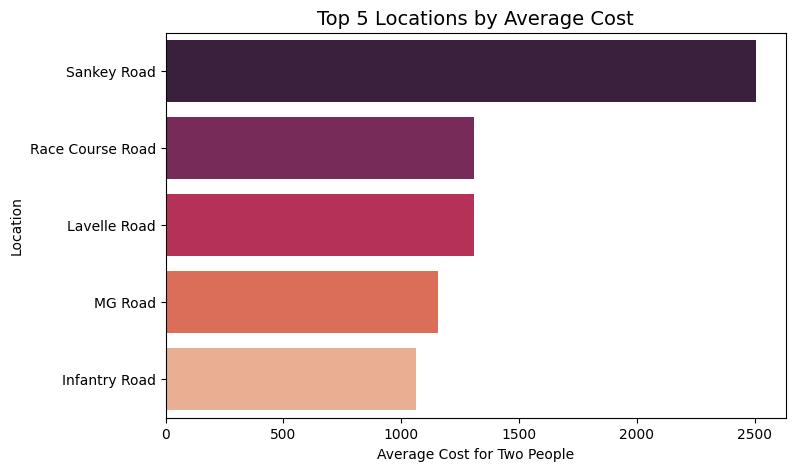

In [36]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=top_cost_locations.values,
    y=top_cost_locations.index,
    hue=top_cost_locations.index,
    palette="rocket",
    legend=False
)

plt.title("Top 5 Locations by Average Cost", fontsize=14)
plt.xlabel("Average Cost for Two People")
plt.ylabel("Location")

plt.show()

### Location vs Cost (Average Expenditure)

The analysis identifies the top 5 locations based on the average cost for two people, reflecting pricing patterns and the presence of premium dining establishments.

- **Sankey Road shows the highest average cost (~2505)**, indicating a strong concentration of high-end or luxury restaurants.
- **Race Course Road and Lavelle Road** also exhibit high average costs, consistent with premium dining clusters.
- **MG Road and Infantry Road** show comparatively lower but still elevated pricing, indicating a mix of upscale and mid-range establishments.

### Key Insights

- High-cost locations are generally associated with **premium dining, fine restaurants, and upscale cafés**.
- These areas typically cater to **high-income customer segments and commercial hubs**.
- The variation in cost across locations highlights a **clear segmentation of the restaurant ecosystem based on pricing tiers**.

### Conclusion

Cost-based location analysis reveals distinct premium clusters within the city. Certain areas are dominated by high-value dining experiences, while others reflect more balanced or mid-range pricing structures, indicating differentiated market positioning across locations.